## 1. Data exploration

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv('data/reddit_posts.csv')

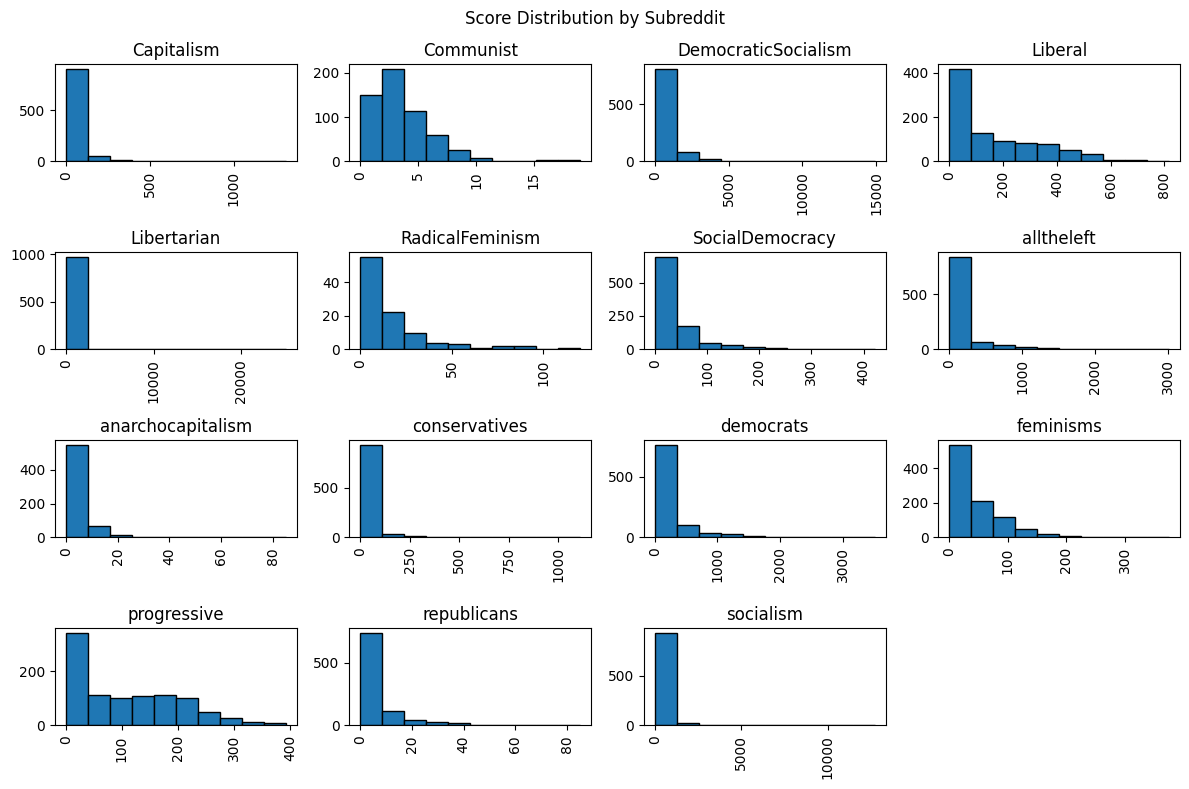

In [3]:

df['Score'].hist(by=df['Subreddit'], edgecolor='black', figsize=(12, 8))

plt.suptitle('Score Distribution by Subreddit')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


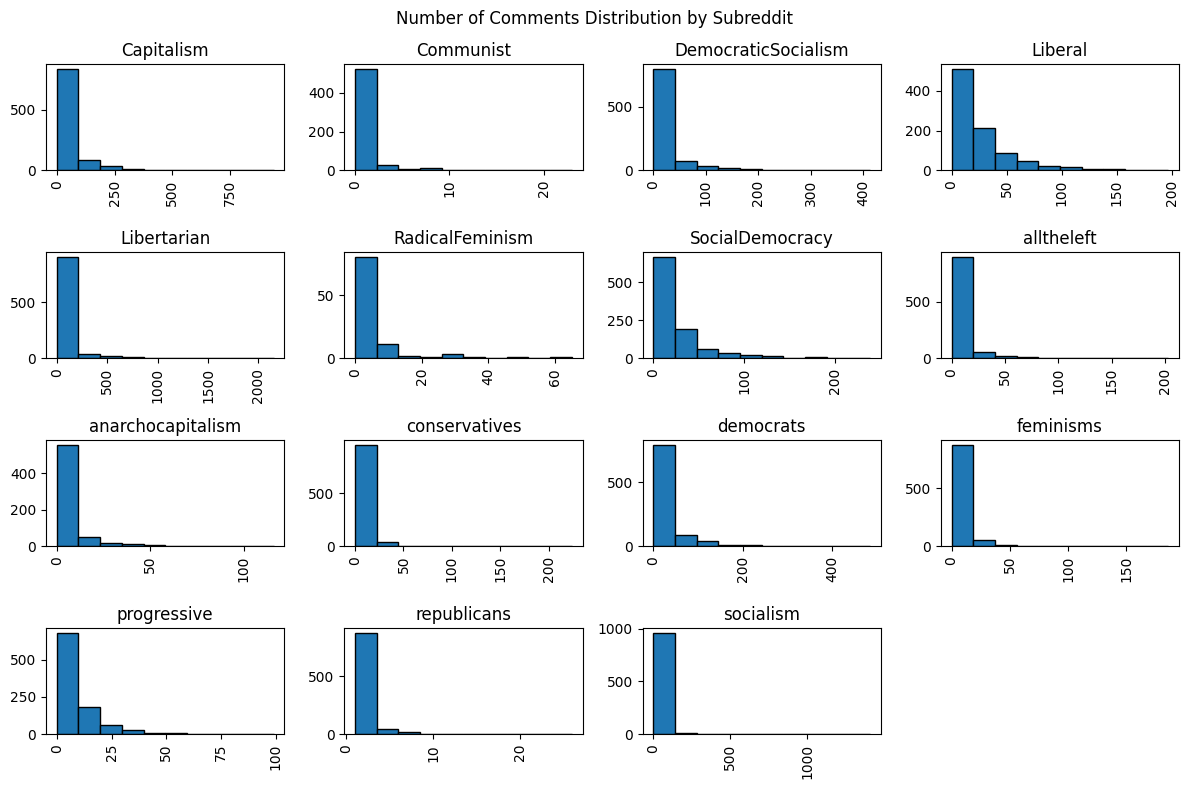

In [4]:
df['Num of Comments'].hist(by=df['Subreddit'], edgecolor='black', figsize=(12, 8))

plt.suptitle('Number of Comments Distribution by Subreddit')
plt.xlabel('Comments')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 2. Data preprocessing

### 2.1 removing urls, and standardising time

In [5]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')
df = df.rename(columns={"Title": "title", "Text": "selftext"})
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

# remove URLs from title and selftext
df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

656 posts contain URLs out of 12854 total


### 2.2 removing stopwords and short tokens

In [6]:
# stop words list
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_str(text):
    if pd.isna(text):
        return ""
    # lowercase
    text = text.lower()
    # remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # split, filter out short tokens & stop-words, then re-join
    tokens = text.split()
    tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
    return " ".join(tokens)

# Apply to title and body, storing cleaned strings
df['title']  = df['title'].apply(clean_str)
df['selftext']   = df['selftext'].apply(clean_str)


### 2.3 lemmatization
To download the model, use 
```py
python -m spacy download en_core_web_sm
```

In [7]:
# if we want to lemmatize
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner","textcat"]  # only need tokenizer, tagger, lemmatizer
)

def clean_str(text: str) -> str:
    if pd.isna(text):
        return ""
    # lowercase & strip non-letters
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    # b) apply spaCy pipeline
    doc = nlp(text)

    # c) filter & lemmatize
    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha             # skip punctuation/numbers
           and not token.is_stop         # skip spaCy’s built-in stop words
           and len(token.lemma_) >= 3    # skip very short lemmas
    ]

    # d) re-join into a cleaned string
    return " ".join(lemmas)

# Apply to your DataFrame in exactly the same way:
df["title"]    = df["title"].apply(clean_str)
df["selftext"] = df["selftext"].apply(clean_str)

## 3. Classificaion

In [8]:
list(df.columns)


['title',
 'Political Lean',
 'Score',
 'Id',
 'Subreddit',
 'URL',
 'Num of Comments',
 'selftext',
 'Date Created']

In [9]:
df.Subreddit.value_counts()

Subreddit
conservatives          1000
alltheleft              997
SocialDemocracy         997
Libertarian             975
Capitalism              975
socialism               975
progressive             974
republicans             948
democrats               941
feminisms               935
DemocraticSocialism     922
Liberal                 904
anarchocapitalism       637
Communist               574
RadicalFeminism         100
Name: count, dtype: int64

### 3.1 prepare the docs and labels for prediction

In [ ]:
# Combine the 'title' and 'selftext'
docs = (df['title'].fillna('') + ' ' + df['selftext'].fillna('')).tolist()

# Encode Subreddit as integers
le = LabelEncoder()
y = le.fit_transform(df['Subreddit'])
subreddit_names = le.classes_


### 3.2 Fit BERTopic and Bet Topic Probabilities

In [ ]:
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)
X = np.array(probs)  # shape: (n_docs, n_topics)


# 3. Evaluate with 5-Fold Cross-Validation (Macro F1)
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
f1_scores = cross_val_score(clf, X, y, cv=5, scoring="f1_macro")
print(f"5-fold CV Macro F1: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=subreddit_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=subreddit_names)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90)
plt.title("Logistic Regression — Subreddit Confusion Matrix")
plt.tight_layout()
plt.show()
